### Importaciones Basicas

In [4]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from pandas.api.types import CategoricalDtype
%matplotlib inline
sns.set(color_codes=True)

### Importaciones

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score, confusion_matrix, classification_report, roc_auc_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, MultiLabelBinarizer
from sklearn.pipeline import make_pipeline
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import RocCurveDisplay

### Cargar data set

In [6]:
df = pd.read_csv("../data/03_primary/weatherAUS_primary.csv")
df.head()

,Date,Year,Month,Month_Name,Location_encoded,Location_name,MinTemp,MaxTemp,Temp_avg,Rainfall,...,Cloud_avg,RainToday,RISK_MM,RainTomorrow,activity_Surf,activity_Senderismo,activity_Buceo,activity_Kayak,activity_Ciclismo,activity_Camping
0,2008-12-01,2008,12,December,2,Albury,13.4,22.9,19.35,0.6,...,8.000,0,0.0,0,0,0,0,0,0,0
1,2008-12-02,2008,12,December,2,Albury,7.4,25.1,20.75,0.0,...,7.750,0,0.0,0,0,0,0,0,0,0
2,2008-12-03,2008,12,December,2,Albury,12.9,25.7,22.10,0.0,...,4.750,0,0.0,0,0,0,0,0,0,0
3,2008-12-04,2008,12,December,2,Albury,9.2,28.0,22.30,0.0,...,6.125,0,1.0,0,0,1,0,1,1,0
4,2008-12-05,2008,12,December,2,Albury,17.5,32.3,23.75,1.0,...,7.500,0,0.2,0,0,0,0,0,0,0


#### Modelo predictivo para Temp_avg

Evaluación del modelo Random Forest:

RMSE: 1.12
MAE: 0.83
R²: 0.97


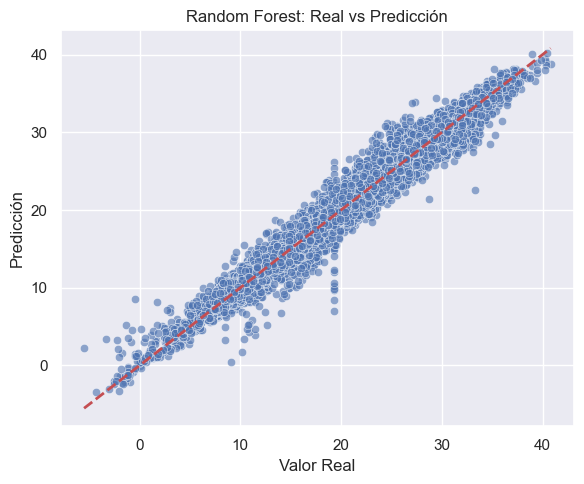

In [7]:
# Variables independientes y dependiente
X = df[['MaxTemp', 'MinTemp', 'Humidity_avg']]  # Features
y = df['Temp_avg']  # Target

# División de datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Modelo Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# Evaluación
mse = mean_squared_error(y_test, y_pred_rf)
rmse = mse ** 0.5
mae = mean_absolute_error(y_test, y_pred_rf)
r2 = r2_score(y_test, y_pred_rf)

print("Evaluación del modelo Random Forest:\n")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R²: {r2:.2f}")

# Gráfico de dispersión Real vs Predicción
plt.figure(figsize=(6, 5))
sns.scatterplot(x=y_test, y=y_pred_rf, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title("Random Forest: Real vs Predicción")
plt.xlabel("Valor Real")
plt.ylabel("Predicción")
plt.tight_layout()
plt.show()

#### Modelo principal modificado

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

# 1. Definir features y targets
features = [
    'Temp_avg', 'WindSpeed_max', 'RainToday', 
    'Rainfall', 'RISK_MM', 'Humidity_avg',
    'Month', 'Location_encoded'
]

activities = [
    'activity_Surf', 
    'activity_Senderismo', 
    'activity_Buceo',
    'activity_Kayak', 
    'activity_Ciclismo', 
    'activity_Camping'
]

# 2. Verificar que las columnas existan en df
available_features = [f for f in features if f in df.columns]
available_activities = [a for a in activities if a in df.columns]

if not available_features:
    raise ValueError("Ningún feature existe en el DataFrame")
if not available_activities:
    raise ValueError("Ninguna actividad existe en el DataFrame")

# 3. Preparar datos
X = df[available_features]
results = {}

# 4. Modelar cada actividad
for activity in available_activities:
    print(f"\n{'='*50}")
    print(f"Modelando actividad: {activity}")
    print(f"{'='*50}")
    
    y = df[activity]
    
    # Dividir datos
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42
    )
    
    # Crear y entrenar modelo
    model = RandomForestClassifier(
        n_estimators=100,
        max_depth=5,
        random_state=42
    )
    model.fit(X_train, y_train)
    
    # Predecir y evaluar
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    
    print(f"\n🔍 Accuracy para {activity}: {accuracy:.2f}")
    print("\n📊 Reporte de Clasificación:")
    print(classification_report(y_test, y_pred))
    
    # Guardar resultados
    results[activity] = {
        'model': model,
        'accuracy': accuracy,
        'classification_report': classification_report(y_test, y_pred, output_dict=True)
    }

# 5. Análisis comparativo
print("\n" + "="*50)
print("RESUMEN DE PREDICCIÓN DE ACTIVIDADES")
print("="*50)

# Listas para gráficos
actividades = []
accuracies = []
precisions = []
recalls = []

for activity, result in results.items():
    print(f"\n🏆 {activity}:")
    print(f"   Accuracy: {result['accuracy']:.2f}")
    print(f"   Precisión (1): {result['classification_report']['1']['precision']:.2f}")
    print(f"   Recall (1): {result['classification_report']['1']['recall']:.2f}")
    
    actividades.append(activity.replace("activity_", ""))
    accuracies.append(result['accuracy'])
    precisions.append(result['classification_report']['1']['precision'])
    recalls.append(result['classification_report']['1']['recall'])



Modelando actividad: activity_Surf

🔍 Accuracy para activity_Surf: 1.00

📊 Reporte de Clasificación:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     30158
           1       0.99      1.00      1.00     12500

    accuracy                           1.00     42658
   macro avg       1.00      1.00      1.00     42658
weighted avg       1.00      1.00      1.00     42658


Modelando actividad: activity_Senderismo

🔍 Accuracy para activity_Senderismo: 0.99

📊 Reporte de Clasificación:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     24945
           1       0.98      1.00      0.99     17713

    accuracy                           0.99     42658
   macro avg       0.99      0.99      0.99     42658
weighted avg       0.99      0.99      0.99     42658


Modelando actividad: activity_Buceo

🔍 Accuracy para activity_Buceo: 1.00

📊 Reporte de Clasificación:
              precision   

#### Testeo de modelo semanal

In [80]:
from datetime import datetime, timedelta
import pandas as pd

def predecir_semana_completa(features_dia, location_id, df, results):

    if 'Day' not in df.columns:
        df['Day'] = pd.to_datetime(df['Date']).dt.day
    if 'Month' not in df.columns:
        df['Month'] = pd.to_datetime(df['Date']).dt.month
    
    predicciones = {}
    hoy = datetime.today().date()
    month_actual = hoy.month
    day_actual = hoy.day

    # 1. Construir vector de features para hoy (agregar Month y Location_encoded)
    x_hoy = features_dia.copy()
    x_hoy['Month'] = month_actual
    x_hoy['Location_encoded'] = location_id
    x_hoy_df = pd.DataFrame([x_hoy])
    
    # 2. Predecir actividades para hoy con los modelos entrenados
    pred_actividades_hoy = {}
    for actividad, res in results.items():
        modelo = res['model']
        pred = modelo.predict(x_hoy_df)[0]
        pred_actividades_hoy[actividad] = pred
    predicciones[hoy] = pred_actividades_hoy
    
    # 3. Para los próximos 6 días (históricos), predecir con datos filtrados por mes y día
    for offset in range(1, 7):
        fecha = hoy + timedelta(days=offset)
        mes = fecha.month
        dia = fecha.day

        # Filtrar histórico para location, mes y día exacto
        df_filtro = df[
            (df['Location_encoded'] == location_id) &
            (df['Month'] == mes) &
            (df['Day'].between(dia - 1, dia + 1))
        ]
        
        if df_filtro.empty:
            df_filtro = df[
                (df['Location_encoded'] == location_id) &
                (df['Month'] == mes)
            ]
        
        if df_filtro.empty:
            df_filtro = df[df['Location_encoded'] == location_id]
        
        if df_filtro.empty:
            predicciones[fecha] = {act: 0 for act in results.keys()}
            continue
        
        # Tomar promedio histórico de features para día actual
        x_hist = {}
        for f in features:
            if f == 'Month':
                x_hist[f] = mes
            elif f == 'Location_encoded':
                x_hist[f] = location_id
            else:
                x_hist[f] = df_filtro[f].mean()
        
        x_hist_df = pd.DataFrame([x_hist])
        
        # Predecir actividades para ese día
        pred_activ_hist = {}
        for actividad, res in results.items():
            modelo = res['model']
            pred = modelo.predict(x_hist_df)[0]
            pred_activ_hist[actividad] = pred
        predicciones[fecha] = pred_activ_hist
    
    return predicciones

In [82]:
# Features meteorológicas del día actual
features_del_dia = {
    'Temp_avg': 22.3,
    'WindSpeed_max': 24.0,
    'RainToday': 0,
    'Rainfall': 0,
    'RISK_MM': 1.0,
    'Humidity_avg': 30.5
}

location_manual = 2

resultado = predecir_semana_completa(features_del_dia, location_manual, df, results)

# Mostrar resultados
print("Predicción actividades próximos 7 días (incluye hoy):\n")
for fecha, preds in resultado.items():
    actividades_habilitadas = [act.replace("activity_", "") for act, val in preds.items() if val == 1]
    if actividades_habilitadas:
        print(f"{fecha}: {actividades_habilitadas}")
    else:
        print(f"{fecha}: Ninguna actividad recomendada")


Predicción actividades próximos 7 días (incluye hoy):

2025-06-23: ['Senderismo', 'Kayak', 'Ciclismo']
2025-06-24: Ninguna actividad recomendada
2025-06-25: Ninguna actividad recomendada
2025-06-26: Ninguna actividad recomendada
2025-06-27: ['Surf']
2025-06-28: Ninguna actividad recomendada
2025-06-29: Ninguna actividad recomendada
